<a href="https://colab.research.google.com/github/miguelmorandini/am-t4-s1a2026/blob/main/MultiNeuralCensus0612.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importar dados do Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Bibliotecas de Python

In [ ]:
!pip -q install plotly
!pip -q install yellowbrick

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

### Carregar Digest de base_census

In [ ]:
import pickle

In [ ]:
with open('/content/drive/MyDrive/DSM/5º Semestre - 2026/aprendizagem-de-maquina/amt4/census.pkl', 'rb') as f:
  X_census_treinamento, Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [ ]:
X_census_treinamento.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [ ]:
X_census_teste.shape, Y_census_teste.shape

((4885, 108), (4885,))

# Pipeline SVM | Digest [Fase 1 census Base]

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from yellowbrick.classifier import ConfusionMatrix

In [ ]:
svm_census = SVC(kernel='rbf', random_state=1, C=2.0)
svm_census.fit(X_census_treinamento, Y_census_treinamento)

SVC(C=2.0, random_state=1)

In [ ]:
SVC(C=2.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=False, random_state=1, shrinking=True, tol=0.001,
    verbose=False)

SVC(C=2.0, random_state=1)

In [ ]:
SVC_previsores = svm_census.predict(X_census_teste)
SVC_previsores

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [ ]:
accuracy_score(Y_census_teste, SVC_previsores)

0.8485158648925282

0.8485158648925282

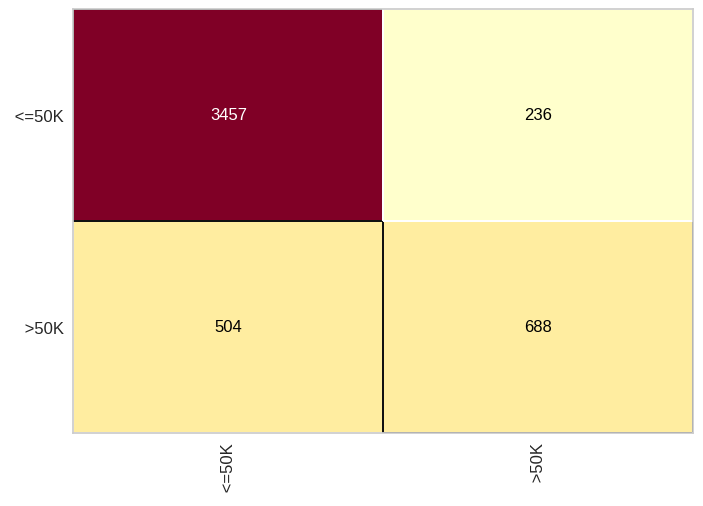

In [ ]:
svm_cm = ConfusionMatrix(svm_census)
svm_cm.fit(X_census_treinamento, Y_census_treinamento)
svm_cm.score(X_census_teste, Y_census_teste)

In [ ]:
print(classification_report(Y_census_teste, SVC_previsores))

              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90      3693
        >50K       0.74      0.58      0.65      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.76      0.78      4885
weighted avg       0.84      0.85      0.84      4885



# Pipeline Redes Neurais | Digest [Fase 1 census Base]

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
redeneural_census = MLPClassifier(verbose=True, max_iter=1000,
                                  tol=0.000010, solver='adam',
                                  hidden_layer_sizes=(100), activation='relu')
redeneural_census.fit(X_census_treinamento, Y_census_treinamento)

Iteration 1, loss = 0.37248596
Iteration 2, loss = 0.32430128
Iteration 3, loss = 0.31382268
Iteration 4, loss = 0.30714566
Iteration 5, loss = 0.30217459
Iteration 6, loss = 0.29881867
Iteration 7, loss = 0.29646417
Iteration 8, loss = 0.29332220
Iteration 9, loss = 0.29159458
Iteration 10, loss = 0.28936186
Iteration 11, loss = 0.28788101
Iteration 12, loss = 0.28585991
Iteration 13, loss = 0.28467926
Iteration 14, loss = 0.28317388
Iteration 15, loss = 0.28127012
Iteration 16, loss = 0.27999119
Iteration 17, loss = 0.27914924
Iteration 18, loss = 0.27780303
Iteration 19, loss = 0.27690100
Iteration 20, loss = 0.27600233
Iteration 21, loss = 0.27511496
Iteration 22, loss = 0.27410382
Iteration 23, loss = 0.27309871
Iteration 24, loss = 0.27160664
Iteration 25, loss = 0.27037274
Iteration 26, loss = 0.26970813
Iteration 27, loss = 0.26873693
Iteration 28, loss = 0.26869302
Iteration 29, loss = 0.26700336
Iteration 30, loss = 0.26640411
Iteration 31, loss = 0.26582552
Iteration 32, los

MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [ ]:
redeneural_census.out_activation_

'logistic'

In [ ]:
previsores_redeneural = redeneural_census.predict(X_census_teste)
previsores_redeneural

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype='<U6')

In [ ]:
accuracy_score(Y_census_teste, previsores_redeneural)

0.822517911975435

0.822517911975435

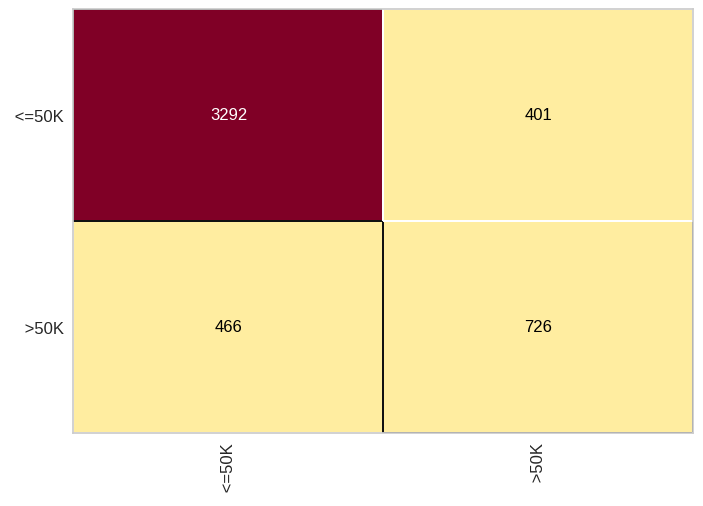

In [ ]:
rm_census = ConfusionMatrix(redeneural_census)
rm_census.fit(X_census_treinamento, Y_census_treinamento)
rm_census.score(X_census_teste, Y_census_teste)

In [ ]:
print(classification_report(Y_census_teste, previsores_redeneural))

              precision    recall  f1-score   support

       <=50K       0.88      0.89      0.88      3693
        >50K       0.64      0.61      0.63      1192

    accuracy                           0.82      4885
   macro avg       0.76      0.75      0.75      4885
weighted avg       0.82      0.82      0.82      4885



# Pipeline de Preparação de Dados | census_Base [Fase 1]

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder_y = LabelEncoder()

Y_census_treinamento = label_encoder_y.fit_transform(Y_census_treinamento)
Y_census_teste = label_encoder_y.transform(Y_census_teste)

In [ ]:
parametros = {'n_neighbors': [3, 5, 10, 20],
              'p':[1,2]}

In [ ]:
grid_census = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros)
grid_census.fit(X_census_treinamento, Y_census_treinamento)
melhor_parametros_census = grid_census.best_params_
melhor_resultado_census = grid_census.best_score_
print(melhor_parametros_census)
print(melhor_resultado_census)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 472, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py", line 446, in score
    return super().score(X, y, sample_weight)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 572, in score
    return accuracy_score(y, self.predict(X), sample_weig

{'n_neighbors': 20, 'p': 2}
0.82941876054117


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan 0.81431549        nan 0.82193938        nan 0.82815413
        nan 0.82941876]
  warnings.warn(


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder_y = LabelEncoder()

Y_census_treinamento = label_encoder_y.fit_transform(Y_census_treinamento)
Y_census_teste = label_encoder_y.transform(Y_census_teste)

In [ ]:
grid_census = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros)
grid_census.fit(X_census_treinamento, Y_census_treinamento)
melhor_parametros_census = grid_census.best_params_
melhor_resultado_census = grid_census.best_score_
print(melhor_parametros_census)
print(melhor_resultado_census)

{'n_neighbors': 20, 'p': 1}
0.8327430212885943
